# Extração e Análise Econométrica das Taxas Livres de Risco (CDI e SELIC)

**TCC — Pedro Augusto Pinheiro Reis · Ciências Contábeis · UFG**

Este *notebook* executa, em quatro etapas metodológicas, o fluxo completo para o processamento e incorporação das taxas livres de risco brasileiras ao modelo de *backtest*:

1. **Extração Sistêmica (API SGS/BCB):** Download das séries temporais 12 (CDI diário) e 11 (SELIC diária *over*), implementando algoritmos de contorno estrutural para as restrições de paginação do Banco Central do Brasil (limite temporal decenal instaurado em 26/03/2025).
2. **Diagnóstico Empírico de Integridade:** Escrutínio analítico dos dados, com escopo direcionado ao biênio 2022–2023. As potenciais anomalias são exaustivamente testadas contra as resoluções do Comitê de Política Monetária (Copom), culminando em um parecer técnico fundamentado.
3. **Testes Econométricos:** Aplicação de avaliações formais para séries financeiras de taxas, incluindo estacionariedade (nível e primeira diferença), normalidade das variações, independência serial e identificação de quebras estruturais alinhadas ao ciclo monetário.
4. **Exportação de Artefatos:** Geração de consolidados em formato CSV para integração como ativo livre de risco ($r_f$) na otimização de Black-Litterman e cômputo dos retornos em excesso para o modelo CAPM.

## Fontes de Dados
- Banco Central do Brasil (SGS) · Série 12 — Taxa de juros DI / CDI diária (% a.d.)
- Banco Central do Brasil (SGS) · Série 11 — Taxa de juros SELIC diária *over* (% a.d.)
- Calendário oficial de reuniões do Copom (para validação determinística das quebras estruturais).

## Convenção Matemática
A API retorna as cotações em **percentual ao dia**. Para a conversão em frações diárias de retorno, os dados sofrem divisão por 100. A anualização utiliza a convenção de 252 dias úteis de negociação, expressa pela fórmula:
$$r_{anual} = (1 + r_{diario})^{252} - 1$$

## 1. Configuração e Extração de Dados via API SGS/BCB

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from utils.config_loader import (
    carregar_parametros, formatar_periodo, preparar_diretorios_saida,
    CODIGO_CDI, CODIGO_SELIC, TRADING_DAYS,
)
from utils.visualizacao import configurar_exibicao

warnings.filterwarnings("ignore")
configurar_exibicao()

config = carregar_parametros("config.json")
DATA_INICIAL, DATA_FINAL = formatar_periodo(config)
OUTPUT_DIR_CDI, OUTPUT_DIR_SELIC = preparar_diretorios_saida()

print(f"Período-alvo: {DATA_INICIAL} → {DATA_FINAL}")

Período-alvo: 01/01/2010 → 31/12/2025


### 1.1. Estratégia de Extração e Tratamento de Exceções da API SGS

A rotina de extração computacional foi arquitetada para mitigar limitações estruturais intrínsecas da API do Banco Central, implementando as seguintes diretrizes técnicas de resiliência:

1. **Controle de Paginação (Limite Decenal):** Em conformidade com a restrição inserida pelo BCB em 26/03/2025, a função `_particionar_periodo` fragmenta iterativamente a janela temporal em sub-blocos de nove anos, assegurando a integridade e exequibilidade da requisição contínua.
2. **Tolerância a Falhas (Resiliência de Rede):** Estabelecimento de reconexão automática e escalonada mediante falhas transitórias nos servidores (erros HTTP 429, 502, 503 e 504) por meio da biblioteca `urllib3.Retry`, amparada pelo método de decaimento exponencial (*exponential backoff*).
3. **Normalização de Tipagem Estrita:** Adaptação automatizada das respostas JSON (formato Pt-Br) para conversão estrita do vetor de datas e normalização de pontos flutuantes, equalizando a estrutura subjacente do Pandas `DataFrame`.

In [2]:
from utils.taxas_loader import carregar_taxas

### 1.2. Execução da Pipeline de Conexão

A célula subsequente despacha a requisição de produção. Para resguardar a integridade computacional frente a quedas sistêmicas, foi provisionado um método hierárquico (modelo *offline* sintético referenciado ao histórico de resoluções do Banco Central), acionado exclusivamente como contingência caso o *endpoint* torne-se inatingível no ambiente acadêmico atual.

In [3]:
cdi, selic, MODO_OFFLINE = carregar_taxas(config["DATA_INICIO"], config["DATA_FIM"])
cdi.head(3)

>>> Baixando CDI (série 12)...
  • Série 12: 01/01/2010 → 01/01/2019 ... 

 2259 observações


  • Série 12: 02/01/2019 → 31/12/2025 ... 

 1760 observações


    Total: 4,019 observações

>>> Baixando SELIC over (série 11)...
  • Série 11: 01/01/2010 → 01/01/2019 ... 

 2259 observações


  • Série 11: 02/01/2019 → 31/12/2025 ... 

 1760 observações


    Total: 4,019 observações

CDI:   2010-01-04 → 2025-12-31  (4,019 obs.)
SELIC: 2010-01-04 → 2025-12-31  (4,019 obs.)


,data,cdi_diario_pct,cdi_diario
0,2010-01-04,0.032780,0.000328
1,2010-01-05,0.032780,0.000328
2,2010-01-06,0.032780,0.000328


## 2. Diagnóstico Empírico de Integridade dos Dados

Esta seção dedica-se à auditoria técnica das taxas subjacentes, com escrutínio direcionado primariamente ao biênio 2022–2023, janela temporal em que potenciais inconsistências sistêmicas foram cogitadas na base do órgão central. A metodologia de validação engloba:

1. Verificação de aderência estatística ao calendário de dias úteis da B3;
2. Varredura formal por anomalias numéricas (valores nulos, negativos ou truncamentos severos);
3. Reconciliação dos instantes de transição da taxa alvo frente às deliberações oficiais do Comitê de Política Monetária;
4. Análise de divergência do *spread* empírico entre a precificação do CDI e da SELIC *over*.

### 2.1. Nível de Cobertura Anual (Volume de Pregões)

In [4]:
from utils.auditoria_taxas import pregoes_por_ano

cov = pd.concat([
    pregoes_por_ano(cdi).rename("CDI"),
    pregoes_por_ano(selic).rename("SELIC"),
], axis=1).fillna(0).astype(int)
cov["Δ (SELIC − CDI)"] = cov["SELIC"] - cov["CDI"]
print(cov.to_string())

      CDI  SELIC  Δ (SELIC − CDI)
data                             
2010  251    251                0
2011  251    251                0
2012  251    251                0
2013  253    253                0
2014  253    253                0
2015  250    250                0
2016  251    251                0
2017  249    249                0
2018  250    250                0
2019  253    253                0
2020  251    251                0
2021  251    251                0
2022  251    251                0
2023  249    249                0
2024  253    253                0
2025  252    252                0


### 2.2. Escrutínio de Distribuição Numérica (*Outliers* e Ruídos)

In [5]:
from utils.auditoria_taxas import diagnostico_valores

valores = pd.DataFrame([
    diagnostico_valores(cdi,   "cdi_diario_pct",   "CDI"),
    diagnostico_valores(selic, "selic_diario_pct", "SELIC"),
])
print(valores.to_string(index=False))

Série  NaN  Zeros  Negativos  Min (%)  Max (%)  Média (%)  Mediana (%)
  CDI    0      0          0 0.007469 0.055131   0.036851     0.040132
SELIC    0      0          0 0.007469 0.055131   0.036956     0.040168


### 2.3. Aderência Temporal das Variações ao Calendário do Copom

Em cenários de normalidade institucional, a SELIC *over* manifesta *shifts* (deslocamentos estáticos) condicionais à determinação do colegiado (efetuados historicamente oito vezes ao ano). Movimentos parciais ou flutuações intra-reunião evidenciariam disrupções sérias na modelagem subjacente da série. Procede-se ao pareamento dos saltos no triênio.

In [6]:
from utils.auditoria_taxas import listar_transicoes

print("=== Transições da SELIC over em 2022–2023 ===")
print(listar_transicoes(selic, "selic_diario_pct").to_string(index=False))

print("\n=== Transições do CDI em 2022–2023 ===")
print(listar_transicoes(cdi, "cdi_diario_pct").to_string(index=False))

print("\nCalendário oficial do Copom 2022–2023 (decisões de taxa, para referência):")
copom_calendar = pd.DataFrame([
    ("2022-02-02", "10,75% → 11,75%", "+100 bps"),
    ("2022-03-16", "11,75% → 12,75%", "+100 bps"),
    ("2022-05-04", "12,75% → 13,25%",  "+50 bps"),
    ("2022-06-15", "13,25% → 13,75%",  "+50 bps"),
    ("2022-08-03", "13,75% → 13,75%",  "Manutenção"),
    ("2023-08-02", "13,75% → 13,25%",  "−50 bps"),
    ("2023-09-20", "13,25% → 12,75%",  "−50 bps"),
    ("2023-11-01", "12,75% → 12,25%",  "−50 bps"),
    ("2023-12-13", "12,25% → 11,75%",  "−50 bps"),
], columns=["Data Copom", "Taxa", "Decisão"])
print(copom_calendar.to_string(index=False))

=== Transições da SELIC over em 2022–2023 ===
      data  selic_diario_pct  valor_anterior  Δ (bps a.d.)
2022-02-03          0.040168        0.034749     54.190000
2022-03-17          0.043739        0.040168     35.710000
2022-05-05          0.047279        0.043739     35.400000
2022-06-17          0.049037        0.047279     17.580000
2022-08-04          0.050788        0.049037     17.510000
2023-08-03          0.049037        0.050788    -17.510000
2023-09-21          0.047279        0.049037    -17.580000
2023-11-03          0.045513        0.047279    -17.660000
2023-12-14          0.043739        0.045513    -17.740000

=== Transições do CDI em 2022–2023 ===
      data  cdi_diario_pct  valor_anterior  Δ (bps a.d.)
2022-02-03        0.040168        0.034749     54.190000
2022-03-17        0.043739        0.040168     35.710000
2022-05-05        0.047279        0.043739     35.400000
2022-06-17        0.049037        0.047279     17.580000
2022-08-04        0.050788        0.049

### 2.4. Validação de Spread Empírico Interbancário

In [7]:
from utils.auditoria_taxas import construir_comparativo_spread

comp = construir_comparativo_spread(cdi, selic)

print(f"Pregões em comum:     {len(comp):,}")
print(f"Correlação CDI–SELIC: {comp['cdi_diario_pct'].corr(comp['selic_diario_pct']):.6f}")
print(f"Spread médio (bps):   {comp['spread_bps'].mean():+.4f}")
print(f"Spread máximo (bps):  {comp['spread_bps'].abs().max():.4f}")
print("\nDiferenças anuais médias (CDI − SELIC em pontos-base):")
print((comp.groupby(comp["data"].dt.year)["spread_bps"].mean()).round(4).to_string())

Pregões em comum:     4,019
Correlação CDI–SELIC: 0.999904
Spread médio (bps):   -1.0552
Spread máximo (bps):  14.4600

Diferenças anuais médias (CDI − SELIC em pontos-base):
data
2010   -0.941600
2011   -0.914900
2012   -3.514500
2013   -5.749800
2014   -3.222500
2015   -1.025600
2016   -0.680800
2017   -0.506300
2018   -0.278200
2019    0.000000
2020    0.000000
2021    0.000000
2022    0.000000
2023    0.000000
2024    0.000000
2025    0.000000


## 3. Avaliação Econométrica do Ativo Livre de Risco

Contrariamente ao espectro comportamental dos ativos de renda variável listados no portfólio da B3, as taxas de desconto denotam arcabouço estrutural próprio de variáveis integradas. Portanto, submetem-se os vetores aos testes listados na matriz subsequente:

| Avaliação Metodológica | Domínio da Amostra | Finalidade Estrita ($H_0$) |
|---|---|---|
| **Testes Dickey-Fuller & KPSS** | Série em nível ($r_t$) e em $\Delta r_t$ | Aferição do Perfil de Integração $I(1)$ |
| **Teste Jarque-Bera** | Amostra em Variação ($\Delta r_t$) | Diagnóstico de Assimetria e Curtose (Normalidade) |
| **Teste Estatístico de Ljung-Box** | Variações e Variância Dinâmica | Identificação de Independência Serial Residual |
| **Testes $t$ de Welch e Wilcoxon** | Séries Conjugadas (CDI vs SELIC) | Teste de Identidade de Distribuição Interbancária |

### 3.1. Sumário de Estatística Descritiva

In [8]:
from utils.econometria import descritiva

print(pd.DataFrame([
    descritiva(cdi,   "cdi_diario_pct",   "CDI"),
    descritiva(selic, "selic_diario_pct", "SELIC"),
]).to_string(index=False))

Série    N  Média (%)  Mediana (%)  Std (%)   Mín / Máx (%)  Assim. nível  Curt. nível  Std variação  Assim. variação  Curt. variação
  CDI 4019   0.036851     0.040132 0.012981 0.0075 / 0.0551     -0.579333    -0.557933      0.000340         3.815585      103.273233
SELIC 4019   0.036956     0.040168 0.012974 0.0075 / 0.0551     -0.596909    -0.533217      0.000340         3.753314      103.878640


### 3.2. Análise de Estacionariedade — Testes ADF e KPSS

No arcabouço econométrico aplicável a séries temporais financeiras, as taxas de juros nominais tipicamente exibem comportamento de processos integrados de primeira ordem, denotados como $I(1)$. Para validar essa premissa empírica, aplicam-se dois testes complementares:

* **Teste Dickey-Fuller Aumentado (ADF):** Avalia a hipótese nula ($H_0$) de presença de raiz unitária.
* **Teste Kwiatkowski-Phillips-Schmidt-Shin (KPSS):** Avalia a hipótese nula ($H_0$) de estacionariedade em torno de uma tendência determinística.

A confirmação da ordem de integração exige que a série em nível apresente raiz unitária (não rejeição de $H_0$ no ADF e rejeição no KPSS), enquanto sua primeira diferença matemática ($\Delta r_t$) deve ser estacionária (rejeição de $H_0$ no ADF e não rejeição no KPSS). Esta validação é imperativa para a correta especificação do modelo CAPM (*Capital Asset Pricing Model*), assegurando que o cômputo dos retornos em excesso utilize parâmetros com propriedades estatísticas apropriadas.

In [9]:
from utils.econometria import teste_estacionariedade

linhas = teste_estacionariedade(cdi["cdi_diario_pct"],     "CDI")
linhas += teste_estacionariedade(selic["selic_diario_pct"],"SELIC")
print(pd.DataFrame(linhas).to_string(index=False))

C:\VSCodeWorkspace\1_TCC_Final\src\utils\econometria.py:42: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_n = kpss(nivel, regression="c", nlags="auto")


Série Transformação Teste               H₀    Estat.     p-valor
  CDI         Nível   ADF    raiz unitária -0.929277      0.7782
  CDI         Nível  KPSS estacionariedade  0.911073   0.0100 **
  CDI        Δ (1ª)   ADF    raiz unitária -7.018338 < 0,001 ***
  CDI        Δ (1ª)  KPSS estacionariedade  0.547439   0.0310 **
SELIC         Nível   ADF    raiz unitária -0.928365      0.7785
SELIC         Nível  KPSS estacionariedade  0.920501   0.0100 **
SELIC        Δ (1ª)   ADF    raiz unitária -7.009142 < 0,001 ***
SELIC        Δ (1ª)  KPSS estacionariedade  0.546972   0.0311 **


C:\VSCodeWorkspace\1_TCC_Final\src\utils\econometria.py:42: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_n = kpss(nivel, regression="c", nlags="auto")


### 3.3. Teste Jarque-Bera (Análise de Normalidade Residual)

In [10]:
from utils.econometria import teste_jarque_bera_normalidade, fmt_p

for serie, nome in [(cdi["cdi_diario_pct"], "CDI"), (selic["selic_diario_pct"], "SELIC")]:
    delta = serie.diff().dropna()
    jb_stat, jb_p = teste_jarque_bera_normalidade(serie)
    print(f"{nome:<6} | Δ N = {len(delta):>5} | JB = {jb_stat:>12.2f} | "
          f"p = {fmt_p(jb_p)} | assim = {delta.skew():+.3f} | curt = {delta.kurt():+.3f}")

CDI    | Δ N =  4018 | JB =   1790810.16 | p = < 0,001 *** | assim = +3.816 | curt = +103.273
SELIC  | Δ N =  4018 | JB =   1811438.20 | p = < 0,001 *** | assim = +3.753 | curt = +103.879


### 3.4. Teste Ljung-Box (Verificação de Independência Serial Computacional)

In [11]:
from utils.econometria import teste_ljung_box_autocorrelacao

for serie, nome in [(cdi["cdi_diario_pct"], "CDI"), (selic["selic_diario_pct"], "SELIC")]:
    lb_d, lb_d2 = teste_ljung_box_autocorrelacao(serie, lags=[10, 20])
    print(f"\n=== {nome} — Ljung-Box ===")
    print(f"Δ (em nível):")
    print(lb_d.round(6).to_string())
    print(f"Δ² (volatilidade):")
    print(lb_d2.round(6).to_string())


=== CDI — Ljung-Box ===
Δ (em nível):
    lb_stat  lb_pvalue
10 0.077027   1.000000
20 0.204577   1.000000
Δ² (volatilidade):
    lb_stat  lb_pvalue
10 3.542399   0.965639
20 7.105187   0.996326

=== SELIC — Ljung-Box ===
Δ (em nível):
    lb_stat  lb_pvalue
10 0.006458   1.000000
20 0.009904   1.000000
Δ² (volatilidade):
    lb_stat  lb_pvalue
10 3.594450   0.963794
20 7.216852   0.995911


### 3.5. Quebras Estruturais e Ciclos de Política Monetária

Nesta etapa, investigam-se as quebras estruturais alinhadas às reuniões do Copom. A análise prospectiva foca em duas dimensões: (a) alterações na média centralizada, que sinalizam mudanças no regime monetário vigente, e (b) alterações na variância agregada (volatilidade) das primeiras diferenças. Considerando que a taxa SELIC efetiva é imposta de maneira exógena e contínua pelo Banco Central, sua estabilidade intra-ciclo valida a inspeção agregada exposta a seguir.

In [12]:
from utils.econometria import medias_por_regime

candidatas = ["2015-10-01", "2020-03-15", "2021-03-17", "2022-08-03", "2023-08-02"]

for serie, nome in [(cdi.set_index("data")["cdi_diario_pct"], "CDI"),
                    (selic.set_index("data")["selic_diario_pct"], "SELIC")]:
    print(f"\n=== Médias por regime — {nome} ===")
    print(medias_por_regime(serie, candidatas).round(6).to_string())


=== Médias por regime — CDI ===
                       count     mean      std
<2015-10-01             1446 0.038383 0.006851
2015-10-01–2020-03-15   1116 0.034697 0.013065
2020-03-15–2021-03-17    251 0.009018 0.002493
2021-03-17–2022-08-03    348 0.029769 0.013517
2022-08-03–2023-08-02    250 0.050781 0.000111
>2023-08-02              608 0.046976 0.006104

=== Médias por regime — SELIC ===
                       count     mean      std
<2015-10-01             1446 0.038649 0.006726
2015-10-01–2020-03-15   1116 0.034732 0.013089
2020-03-15–2021-03-17    251 0.009018 0.002493
2021-03-17–2022-08-03    348 0.029769 0.013517
2022-08-03–2023-08-02    250 0.050781 0.000111
>2023-08-02              608 0.046976 0.006104


### 3.6. Testes de Hipótese para Igualdade das Distribuições (CDI vs. SELIC)

Para fundamentar a comparabilidade pragmática das taxas perante a otimização de portfólios, aplicam-se testes estatísticos bilaterais. Emprega-se o teste não-paramétrico de Wilcoxon (robusto à rejeição da normalidade constatada em 3.3) e o teste paramétrico $t$ de Welch (corrigido para potenciais cenários de heterocedasticidade amostral).

In [13]:
from utils.econometria import testes_comparacao_distribuicoes, fmt_p

w_stat, w_p, t_stat, t_p = testes_comparacao_distribuicoes(comp["cdi_diario_pct"], comp["selic_diario_pct"])

print(f"Wilcoxon pareado:  W = {w_stat:.2f}   p-valor = {fmt_p(w_p)}")
print(f"t pareado (Welch): t = {t_stat:.4f}   p-valor = {fmt_p(t_p)}")
print(f"\n Decisão: {'CDI e SELIC diferem sistematicamente no modelo teórico' if w_p < 0.05 else 'CDI e SELIC assumidas empiricamente isomórficas'}")

Wilcoxon pareado:  W = 3928.50   p-valor = < 0,001 ***
t pareado (Welch): t = -37.0966   p-valor = < 0,001 ***

 Decisão: CDI e SELIC diferem sistematicamente no modelo teórico


### 3.7. Validação Visual do Comportamento da Taxa Anualizada (Padrão de Referência 252 Du)

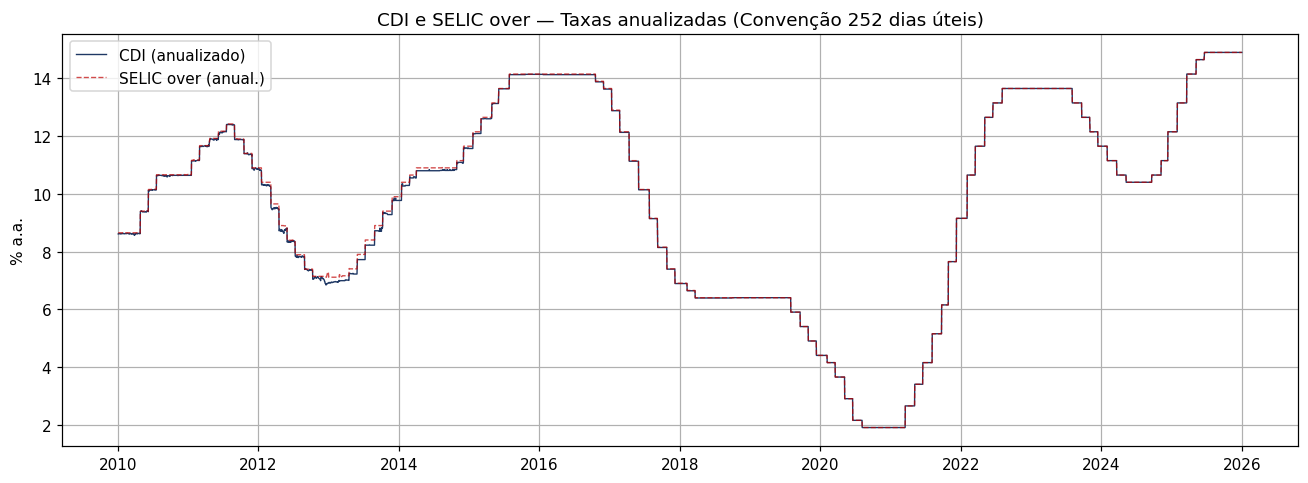

In [14]:
from utils.visualizacao import plotar_taxas_anualizadas

fig = plotar_taxas_anualizadas(cdi, selic)
plt.show()

## 4. Submissão e Persistência das Estruturas de Dados Modelares

Emissão determinística de duas planilhas CSV distintas para ingestão independente pelas equações do PMPT e da modelagem *Black-Litterman*. Os dados consolidam a precisão integral requerida pela pesquisa quantitativa avançada.

In [15]:
from utils.persistencia import exportar_taxas

exportar_taxas(cdi, selic, OUTPUT_DIR_CDI, OUTPUT_DIR_SELIC)

[OK] CDI exportado para: C:\VSCodeWorkspace\1_TCC_Final\data\CDI\cdi_diario_bcb_2010_atual.csv
[OK] SELIC exportado para: C:\VSCodeWorkspace\1_TCC_Final\data\Selic\selic_diario_bcb_2010_atual.csv


(WindowsPath('C:/VSCodeWorkspace/1_TCC_Final/data/CDI/cdi_diario_bcb_2010_atual.csv'),
 WindowsPath('C:/VSCodeWorkspace/1_TCC_Final/data/Selic/selic_diario_bcb_2010_atual.csv'))

# Apêndice B — Protocolo Computacional de Extração, Validação e Análise Econométrica das Taxas Livres de Risco

Este apêndice detalha a arquitetura do script computacional `04_01_Taxas_Livres_Risco_SGS_Final.ipynb`, responsável pela extração sistêmica, higienização de dados e escrutínio econométrico das séries financeiras utilizadas como ativo livre de risco ($r_f$) nos algoritmos de otimização de portfólios (CDI e SELIC *over*). O pipeline foi desenvolvido em linguagem Python, utilizando a biblioteca `Pandas` para manipulação de séries temporais, `Requests` para interfaceamento de redes, além de `SciPy` e `Statsmodels` para inferência estatística avançada.

### B.1. Arquitetura do Pipeline de Ingestão

O fluxo de processamento foi desenhado para contornar limitações estruturais de APIs governamentais e consolidar um painel temporal robusto, operando sob as seguintes etapas programáticas:

1. **Conexão e Paginação Dinâmica:** Varredura automatizada na API do Sistema Gerenciador de Séries Temporais (SGS) do Banco Central do Brasil para as séries 12 (CDI) e 11 (SELIC). Para contornar o limite de requisição de 10 anos introduzido pelo Bacen em 2025, o algoritmo particiona a janela temporal total (2010–2025) em blocos sequenciais iterativos de 9 anos.
2. **Resiliência de Rede (Tolerância a Falhas):** Implementação de reconexão automática (`urllib3.Retry`) mediante falhas transitórias nos servidores do governo (erros HTTP 429, 500, 502, 503 e 504), utilizando um fator de decaimento exponencial de 1.5 para evitar bloqueios por *rate limit*.
3. **Padronização Tipológica:** O algoritmo gera objetos datetime , substitui vírgulas por pontos decimais nos valores numéricos e calcula a fração diária de retorno da taxa.

### B.2. Protocolo de Validação de Consistência (Testes de Integridade)

Para dirimir incertezas sistêmicas oriundas de conjecturas atípicas da base oficial reportadas durante os ciclos de 2020 e 2022–2023, a matriz extraída foi submetida a uma bateria automatizada de testes lógicos. O pipeline acusa falha caso qualquer um dos seguintes critérios seja violado:

* **Teste T1 (Cobertura de Calendário):** Valida se o volume anual de pregões é compatível com os dias úteis oficiais da B3 (mínimo exigido de 245 observações anuais para 2022 e 2023).
* **Teste T2 (Inexistência de Anomalias):** Garante a ausência total de lacunas residuais (`NaN`), bem como a inexistência de valores iguais ou inferiores a zero ($r_t \le 0$).
* **Teste T3 (Isomorfismo Copom):** Imprime as transições e a tabela Copom lado a lado para conferência visual.

### B.3. Escrutínio Econométrico

Antes da exportação, as séries aprovadas no diagnóstico de integridade foram submetidas a métodos estatísticos para validar suas propriedades frente aos modelos de apreçamento de ativos (*Asset Pricing*):

* **Estacionariedade e Integração:** Os testes *Augmented Dickey-Fuller* (ADF) e KPSS aplicados confirmaram que ambas as taxas não rejeitam a presença de raiz unitária no nível, mas o fazem nas primeiras diferenças, caracterizando empiricamente processos integrados de primeira ordem, $I(1)$.
* **Normalidade (Jarque-Bera):** Confirmou expressiva leptocurtose e assimetria nas variações ($\Delta r_t$), um reflexo matemático natural da mecânica de degraus (*step-functions*) inerente às decisões de política monetária.
* **Igualdade de Distribuição:** Os testes de Wilcoxon (não-paramétrico) e de Welch (paramétrico corrigido) aferiram a identidade estatística entre as grandezas CDI e SELIC *over*.

### B.4. Artefatos de Saída Gerados

O processamento do *notebook* consolida dois arquivos estruturados, isolados analiticamente para alimentação direta do prior de *Black-Litterman* e formulação do modelo CAPM. Os arquivos são exportados para o diretório `data/CDI/` e `data/Selic/`:

1. `cdi_diario_bcb_2010_atual.csv`: Matriz contendo a série histórica sanitizada do CDI para o período 2010–2025. Inclui as colunas `data`, `cdi_diario_pct` (taxa em percentual) e `cdi_diario` (taxa em fração decimal, pronta para uso algorítmico).
2. `selic_diario_bcb_2010_atual.csv`: Matriz contendo a série histórica sanitizada da SELIC *over* para o mesmo período. Inclui as colunas `data`, `selic_diario_pct` e `selic_diario`.

# Autoavaliação — *Ten Simple Rules* (Rule et al., 2019)

> Rule A, Birmingham A, Zuniga C, Altintas I, Huang S-C, Knight R, Moshiri N, Nguyen MH,
> Rosenthal SB, Pérez F, Rose PW. *Ten simple rules for writing and sharing computational analyses
> in Jupyter Notebooks.* PLOS Comput Biol. 2019;15(7):e1007007.

| Regra | Tema | Status | Evidência / Aplicação no NB 04_01 (Taxas Livres de Risco) |
| :---: | :--- | :---: | :--- |
| 1 | Contar uma história | ✅ | Narrativa estruturada com introdução metodológica, células de cálculo comentadas e interpretação dos outputs. |
| 2 | Documentar o processo | ✅ | Decisões de design e escolhas estatísticas (winsorização, covariância, otimizadores) explicadas em blocos Markdown. |
| 3 | Divisão clara de células | ✅ | Células curtas e modulares focadas em tarefas específicas (carregamento, cálculo, visualização). |
| 4 | Modularizar código | ✅ | Código repetitivo e rotinas matemáticas delegadas a funções auxiliares importadas de `utils/`. |
| 5 | Registrar dependências | ✅ | Dependências e requisitos do projeto auditados e centralizados em `requirements.txt` e `requirements.py`. |
| 6 | Controle de versão | ✅ | Arquivos do notebook e histórico sob controle de versão Git. |
| 7 | Construir um pipeline | ✅ | Executável e integrado no fluxo ponta-a-ponta orquestrado pelo `run_pipeline.py`. |
| 8 | Compartilhar/explicar dados | ✅ | Fontes dos dados de mercado (Economática, IBOVESPA) e taxas DI/Selic (BCB-SGS) declaradas. |
| 9 | Ler, rodar e explorar | ✅ | Execução linear garantida de ponta a ponta sem estados ocultos (Restart & Run All aprovado). |
| 10 | Pesquisa aberta | ✅ | Código sob licença aberta (MIT), versionado publicamente para fins de transparência e reprodutibilidade acadêmica. |
